In [1]:
import pandas as pd
import numpy as np

from gpcam import GPOptimizer

import time

from PIL import Image
import ot
import os
import glob

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Load images

In [ ]:

# ── Load images ───────────────────────────────────────────────────────────────
IMAGE_DIR        = 'Data/images'
all_paths   = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.png')))

# ── Load distance matrices ───────────────────────────────────────────────
wd_filename  = 'Data/wasserstein_distances_full.npy'
swd_filename = 'Data/sliced_wasserstein_distances_full.npy'

WD_matrix  = np.load(wd_filename)
SWD_matrix = np.load(swd_filename)

# ── output ───────────────────────────────────────────────
y = np.load('Data/y_modulus.npy')

# Seperating Training and Testing Data

In [4]:
# ── Choose metric ─────────────────────────────────────────────────────────────
distance_full = SWD_matrix # Choose between WD_matrix and SWD_matrix

# ── Indices as X ──────────────────────────────────────────────────────────────
indices = np.arange(len(y))   # [0, 1, 2, ..., 19]

# ── Split ─────────────────────────────────────────────────────────────────────
x_train, x_test, y_train, y_test = train_test_split(
    indices, y,
    # test_size=0.3,      # 80/20 split 
    train_size=250,      # exactly 250 random training points
    random_state=3345
)

x_train = x_train.reshape(-1,1)
x_test = x_test.reshape(-1,1)

print('Done')

Done


# GP Model

In [5]:
# Step 2: Define the basic GP components

def matern_kernel_diff1(distance, length):
    kernel = (1.0 + ((np.sqrt(3.0) * distance) / length)) * np.exp(
        -(np.sqrt(3.0) * distance) / length
    )
    return kernel


def my_kernel(x1, x2, hps):
    """
    x1, x2: arrays of indices (either train_idx or test_idx)
    """
    # x1 and x2 ARE the indices - just extract them
    x1_idx = x1.astype(int).flatten()
    x2_idx = x2.astype(int).flatten()
    
    # Get distances from full precomputed matrix
    my_distance = distance_full[np.ix_(x1_idx, x2_idx)]
    
    # Apply Matern kernel
    k = hps[0] * matern_kernel_diff1(my_distance, hps[1])
    
    return k


def my_noise(x, hps):
    s = np.ones(len(x)) * hps[2]
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * hps[3]
    return m

In [6]:

# Define hyperparameter bounds
bounds = np.empty((4, 2))
bounds[0] = np.array([1e-0, 1e4])   # 1                                           # sigma_f: signal variance      
bounds[1] = np.array([1e-3,5])       # length_scale: bump radius
bounds[2] = np.array([1e-5, 10 ])                                             # mean function offset         
bounds[3] = np.array([0, 10])                                             # mean function offset         

print(f"\nHyperparameter bounds:")
print(f"  Signal variance: [{bounds[0, 0]:.6f}, {bounds[0, 1]:.6f}]")
print(f"  length:      [{bounds[1, 0]:.6f}, {bounds[1, 1]:.6f}]")
print(f"  Noise:            [{bounds[2, 0]:.6f}, {bounds[2, 1]:.6f}]")
print(f"  Mean:            [{bounds[3, 0]:.6f}, {bounds[3, 1]:.6f}]")


Hyperparameter bounds:
  Signal variance: [1.000000, 10000.000000]
  length:      [0.001000, 5.000000]
  Noise:            [0.000010, 10.000000]
  Mean:            [0.000000, 10.000000]


In [7]:
# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)
print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(x_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=my_kernel,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)
print(f"Initial log likelihood: {initial_log_likelihood:.6f}")

# Step 5: Train the GP model
t0 = time.time()
my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='global', max_iter=10000)
t1 = time.time()
print(f"Training completed in {t1 - t0:.2f} seconds.")   

# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")


Initial hyperparameters: [5.000500e+03 2.500500e+00 5.000005e+00 5.000000e+00]
Initial log likelihood: -488.519136
Training completed in 4.30 seconds.
Final hyperparameters:   [3.89516830e+03 4.86021501e-01 4.50885962e-05 6.93960204e+00]
Final log likelihood:    -210.67


Posterior mean computed in 0.00 seconds
RMSE: 0.00012900850988964617


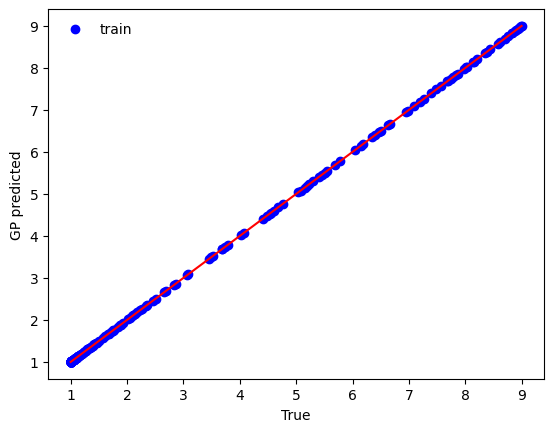

In [9]:
t0 = time.time()
f_train = my_gpo.posterior_mean(x_train)["m(x)"]
t1 = time.time()
print(f"Posterior mean computed in {t1 - t0:.2f} seconds")

my_line = np.linspace(np.min(y_train),np.max(y_train),10)

print('RMSE:', my_gpo.rmse(x_train,y_train)) # *100/np.mean(y_train),'%')

plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

RMSE: 0.4922164733074545


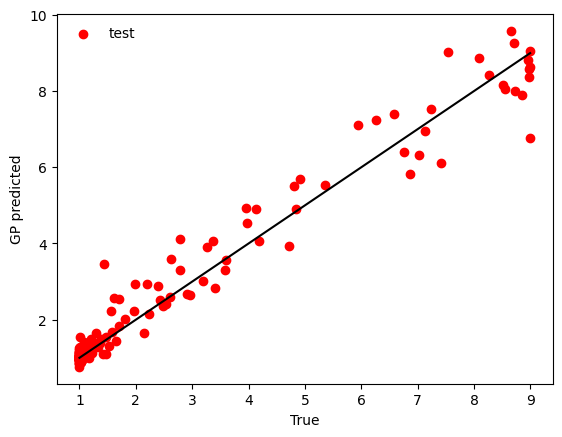

In [9]:
f = my_gpo.posterior_mean(x_test)["m(x)"]
posterior_var = my_gpo.posterior_covariance(x_test, variance_only=True, add_noise=False) # it does not matter if we added noise because it is 1e-6
var = posterior_var["v(x)"].flatten()

print('RMSE:', my_gpo.rmse(x_test,y_test)) # *100/np.mean(y_train),'%')


my_line = np.linspace(np.min(y_test),np.max(y_train),10)

plt.scatter(y_test,f,color="red",label = 'test')
plt.plot(my_line,my_line,c="black")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

# Multiple GPs

In [10]:
import numpy as np
import random
import json
from tqdm import tqdm
from gpcam import GPOptimizer
import os
import time

from scipy.stats import norm


In [ ]:
# ── Load distance matrices ───────────────────────────────────────────────
wd_filename  = 'Data/wasserstein_distances_full.npy'
swd_filename = 'Data/sliced_wasserstein_distances_full.npy'

# WD_matrix  = np.load(wd_filename)
SWD_matrix = np.load(swd_filename)

ground_truth =  np.load('Data/y_modulus.npy')

distance_full = SWD_matrix 


In [12]:
# Step 2: Define the basic GP components

def matern_kernel_diff1(distance, length):
    kernel = (1.0 + ((np.sqrt(3.0) * distance) / length)) * np.exp(
        -(np.sqrt(3.0) * distance) / length
    )
    return kernel


def my_kernel(x1, x2, hps):
    # x1 and x2 ARE the indices - just extract them
    x1_idx = x1.astype(int).flatten()
    x2_idx = x2.astype(int).flatten()
    
    # Get distances from full precomputed matrix
    my_distance = distance_full[np.ix_(x1_idx, x2_idx)]
    
    # Apply Matern kernel
    k = hps[0] * matern_kernel_diff1(my_distance, hps[1])
    
    return k


def my_noise(x, hps):
    s = np.ones(len(x)) * hps[2] # FIXED: was 10^-5
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * hps[3]
    return m

bounds = np.empty((4, 2))
bounds[0] = np.array([1e-0, 1e4])   # 1                                           # sigma_f: signal variance
bounds[1] = np.array([1e-3,5])       # length_scale: bump radius
bounds[2] = np.array([1e-5, 10 ])                                             # mean function offset
bounds[3] = np.array([0, 10])                                             # mean function offset



In [ ]:

def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

def load_or_create_results_file(filename='gp_experiment_results.json'):
    """Load existing results or create new file"""
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            try:
                existing_results = json.load(f)
                print(f"Loaded {len(existing_results)} existing results")
                return existing_results
            except:
                print("Creating new results file")
                return []
    else:
        print("Creating new results file")
        return []

def get_test_data(configs, ground_truth):
    """Get the fixed test data"""
    x_test = np.array(configs['test_indices']).reshape(-1,1)
    y_test = ground_truth[x_test].flatten()
    return x_test, y_test

def get_training_data(configs, training_size, trial_number, ground_truth):
    """Get training data for specific configuration"""
    
    trial = configs['training_configurations'][str(training_size)][trial_number]
    
    seed = trial['seed']
    
    indices_train = np.array(trial['indices_train'])        
    x_train       = indices_train.reshape(-1, 1)            
    y_train       = ground_truth[indices_train]
    
    return x_train, y_train, seed, indices_train

def train_gp_model(x_train, y_train, bounds):
    """Train GP model with your existing setup"""
    
    # Initial hyperparameters (middle of bounds)
    init_hps = np.mean(bounds, axis=1)
    
    # Initialize GPOptimizer
    my_gpo = GPOptimizer(x_train, y_train,
                         init_hyperparameters=init_hps,
                         kernel_function=my_kernel,
                         prior_mean_function=my_mean, 
                         noise_function=my_noise)
    
    # Train the GP model
    my_gpo.train(hyperparameter_bounds=bounds, 
                 init_hyperparameters=init_hps, 
                 method='global', 
                 max_iter=10000)
    
    return my_gpo

def picp(gp_model_object, x_test, y_true, interval=0.95):
        mu = gp_model_object.posterior_mean(x_test)["m(x)"]
        sigma = np.sqrt(gp_model_object.posterior_covariance(x_test, add_noise=True)["v(x)"])

        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp
   

def save_results_incremental(results, filename='gp_experiment_results.json'):
    """Save results incrementally"""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

def check_if_already_done(existing_results, train_size, trial_idx):
    """Check if this experiment was already completed"""
    for result in existing_results:
        if (result.get('training_size') == train_size and 
            result.get('trial') == trial_idx):
            return True
    return False

def run_complete_gp_experiments():
    """Run all GP experiments and save results incrementally"""
    
    # Load configurations
    print("Loading configurations...")
    json_file_name = 'Data/saxs_training_configurations.json'
    configs = load_configurations(json_file_name)
    
    # Load existing results or create new
    results_filename = 'Data/Matern_Sliced_Wass.json'
    all_results = load_or_create_results_file(results_filename)
    
    # Get fixed test data
    #print("Loading test data...")
    x_test, y_test = get_test_data(configs, ground_truth)
    print(f"Test data: {x_test.shape}")

    # Get all training sizes
    # training_sizes = list(configs['training_configurations'].keys())
    # training_sizes = [int(size) for size in training_sizes]
    # training_sizes.sort()

    training_sizes = [150, 200, 250]

    
    # Main experiment loop
    for train_size in training_sizes:
        print(f"\n=== Training Size: {train_size} ===")
        
        trials = configs['training_configurations'][str(train_size)]
        
        #for trial_idx in tqdm(range(len(trials)), desc=f"Size {train_size}"):
        for trial_idx in tqdm(range(30), desc=f"Size {train_size}"):
    
            # Skip if already completed
            if check_if_already_done(all_results, train_size, trial_idx):
                print(f"  ⏭️ Skipping trial {trial_idx} (already completed)")
                continue
            
            try:
                # Get training data for this trial
                x_train, y_train, seed, indices_train = get_training_data(configs, train_size, trial_idx, ground_truth)

                # Train GP model
                my_gpo = train_gp_model(x_train, y_train, bounds)
                
                # Calculate training RMSE
                train_rmse = my_gpo.rmse(x_train, y_train)
                
                # Calculate testing RMSE
                test_rmse = my_gpo.rmse(x_test, y_test)

                # Compute CRPS
                crps_test = my_gpo.crps(x_test, y_test)

                # Compute picp
                picp_test = picp(my_gpo, x_test, y_test)
                
                # Get final hyperparameters and log likelihood
                final_hps = my_gpo.get_hyperparameters()
                final_ll = my_gpo.log_likelihood(final_hps)
                
                # Store results
                result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': seed,
                    'train_rmse': float(train_rmse),
                    'test_rmse': float(test_rmse),
                    'test_crps mean': float(crps_test[0]),
                    'test_crps std': float(crps_test[1]),
                    'test_picp': float(picp_test),
                    'final_log_likelihood': float(final_ll),
                    'final_hyperparameters': final_hps.tolist(),
                    'n_training_points': len(x_train),
                }
                
                all_results.append(result)
                
                # Save after each trial
                save_results_incremental(all_results, results_filename)
                
                # Print progress for first few trials
                if trial_idx < 3:
                    print(f"Trial {trial_idx}: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f} Saved")
                
            except Exception as e:
                print(f"Trial {trial_idx} failed: {str(e)}")
                
                # Save failed result too
                failed_result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': trials[trial_idx]['seed'],
                    'error': str(e),
                    'status': 'failed',
                    'completed_at': time.strftime('%Y-%m-%d %H:%M:%S')
                }
                all_results.append(failed_result)
                save_results_incremental(all_results, results_filename)
                continue
    
    return all_results

print("Starting GP experiments...")
print("="*60)

# Run experiments
results = run_complete_gp_experiments()

print("="*60)
print(f"Completed! Total experiments: {len(results)}")

Starting GP experiments...
Loading configurations...
Creating new results file
Test data: (100, 1)

=== Training Size: 150 ===


Size 150:   3%|▎         | 1/30 [00:01<00:41,  1.43s/it]

Trial 0: Train RMSE=0.0550, Test RMSE=0.6708 Saved


Size 150:   7%|▋         | 2/30 [00:02<00:36,  1.31s/it]

Trial 1: Train RMSE=0.0051, Test RMSE=0.5502 Saved


...

Trial 1: Train RMSE=0.1936, Test RMSE=0.6170 Saved


Size 250:  10%|█         | 3/30 [00:09<01:28,  3.29s/it]

Trial 2: Train RMSE=0.0001, Test RMSE=0.5488 Saved


Size 250: 100%|██████████| 30/30 [01:52<00:00,  3.75s/it]

Completed! Total experiments: 90
